In [1]:
import os
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
 
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize
 
print("Libraries loaded!")
print(f"PyTorch version: {torch.__version__}")

Libraries loaded!
PyTorch version: 2.10.0+cu128


In [2]:
BASE_DIR = '/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000'
df = pd.read_csv(f'{BASE_DIR}/HAM10000_metadata.csv')

img_dir_1 = f'{BASE_DIR}/HAM10000_images_part_1'
img_dir_2 = f'{BASE_DIR}/HAM10000_images_part_2'

def get_img_path(img_id):
    p1 = os.path.join(img_dir_1, img_id + '.jpg')
    p2 = os.path.join(img_dir_2, img_id + '.jpg')
    return p1 if os.path.exists(p1) else p2

df['path'] = df['image_id'].apply(get_img_path)
label_map = {'nv':0, 'mel':1, 'bkl':2, 'bcc':3, 'akiec':4, 'vasc':5, 'df':6}
label_names = ['nv', 'mel', 'bkl', 'bcc', 'akiec', 'vasc', 'df']
df['label'] = df['dx'].map(label_map)

print("Data loaded!")
print(df['dx'].value_counts())

Data loaded!
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


In [3]:
class SkinDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
 
    def __len__(self):
        return len(self.df)
 
    def __getitem__(self, idx):
        img = Image.open(self.df.loc[idx, 'path']).convert('RGB')
        label = self.df.loc[idx, 'label']
        if self.transform:
            img = self.transform(img)
        return img, label
 
print("Dataset class defined!")

Dataset class defined!


In [4]:
# !! For InceptionV3: use 299x299
# !! For ResNet50 / EfficientNet: use 224x224
IMG_SIZE = 299  # <-- change to 224 for ResNet50 / EfficientNet
 
train_df, temp_df = train_test_split(
    df, test_size=0.2, stratify=df['label'], random_state=42)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42)
 
print(f'Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}')
 
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
 
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
 
train_loader = DataLoader(SkinDataset(train_df, train_transform),
                          batch_size=32, shuffle=True, num_workers=2)
val_loader   = DataLoader(SkinDataset(val_df, val_transform),
                          batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(SkinDataset(test_df, val_transform),
                          batch_size=32, shuffle=False, num_workers=2)
 
print("DataLoaders ready!")
 

Train: 8012, Val: 1001, Test: 1002
DataLoaders ready!


In [5]:
# !! CHANGE THIS BLOCK FOR EACH MODEL !!
 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
 
counts = df['label'].value_counts().sort_index().values
weights = 1.0 / counts
weights = weights / weights.sum() * len(counts)
class_weights = torch.FloatTensor(weights).to(device)
 
# ── Option A: InceptionV3 (IMG_SIZE=299) ──────────────────────────────
MODEL_NAME = 'InceptionV3'
model = models.inception_v3(pretrained=True, aux_logits=True)
model.fc = nn.Linear(model.fc.in_features, 7)
model.AuxLogits.fc = nn.Linear(model.AuxLogits.fc.in_features, 7)
model = model.to(device)
 
# ── Option B: ResNet50 (IMG_SIZE=224) — uncomment to use ──────────────
# MODEL_NAME = 'ResNet50'
# model = models.resnet50(pretrained=True)
# model.fc = nn.Linear(model.fc.in_features, 7)
# model = model.to(device)
 
# ── Option C: EfficientNet-B0 (IMG_SIZE=224) — uncomment to use ───────
# from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
# MODEL_NAME = 'EfficientNet-B0'
# model = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
# model.classifier[1] = nn.Linear(model.classifier[1].in_features, 7)
# model = model.to(device)
 
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
 
# Cosine annealing scheduler
NUM_EPOCHS = 15
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)
 
print(f"Model: {MODEL_NAME}")
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

Using device: cuda


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 221MB/s] 


Model: InceptionV3
Total parameters: 24,362,990


In [6]:
train_losses, val_losses, val_accs = [], [], []
best_val_loss = float('inf')
 
for epoch in range(NUM_EPOCHS):
    # ── Training ──
    model.train()
    running_loss = 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
 
        # InceptionV3 has aux output; others don't
        if MODEL_NAME == 'InceptionV3':
            outputs, aux = model(imgs)
            loss = criterion(outputs, labels) + 0.4 * criterion(aux, labels)
        else:
            outputs = model(imgs)
            loss = criterion(outputs, labels)
 
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
 
    train_losses.append(running_loss / len(train_loader))
    scheduler.step()
 
    # ── Validation ──
    model.eval()
    correct, total, val_loss = 0, 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)
 
    val_losses.append(val_loss / len(val_loader))
    val_accs.append(100. * correct / total)
 
    # Save best model
    if val_losses[-1] < best_val_loss:
        best_val_loss = val_losses[-1]
        torch.save(model.state_dict(), f'{MODEL_NAME}_best.pth')
 
    print(f'Epoch {epoch+1:2d}/{NUM_EPOCHS} | '
          f'Train Loss: {train_losses[-1]:.4f} | '
          f'Val Loss: {val_losses[-1]:.4f} | '
          f'Val Acc: {val_accs[-1]:.2f}% | '
          f'LR: {scheduler.get_last_lr()[0]:.6f}')
 
print(f'\nBest Val Loss: {best_val_loss:.4f}')

Epoch  1/15 | Train Loss: 1.7124 | Val Loss: 1.0996 | Val Acc: 62.64% | LR: 0.000099
Epoch  2/15 | Train Loss: 1.1360 | Val Loss: 0.9700 | Val Acc: 62.54% | LR: 0.000096
Epoch  3/15 | Train Loss: 0.9187 | Val Loss: 0.5552 | Val Acc: 72.03% | LR: 0.000091
Epoch  4/15 | Train Loss: 0.7680 | Val Loss: 0.5240 | Val Acc: 74.83% | LR: 0.000084
Epoch  5/15 | Train Loss: 0.6352 | Val Loss: 0.5700 | Val Acc: 72.23% | LR: 0.000075
Epoch  6/15 | Train Loss: 0.5422 | Val Loss: 0.6722 | Val Acc: 78.72% | LR: 0.000066
Epoch  7/15 | Train Loss: 0.4372 | Val Loss: 0.4997 | Val Acc: 83.02% | LR: 0.000056
Epoch  8/15 | Train Loss: 0.4300 | Val Loss: 0.6028 | Val Acc: 81.62% | LR: 0.000045
Epoch  9/15 | Train Loss: 0.3379 | Val Loss: 0.6242 | Val Acc: 83.12% | LR: 0.000035
Epoch 10/15 | Train Loss: 0.2805 | Val Loss: 0.4866 | Val Acc: 82.82% | LR: 0.000026
Epoch 11/15 | Train Loss: 0.2263 | Val Loss: 0.5236 | Val Acc: 85.31% | LR: 0.000017
Epoch 12/15 | Train Loss: 0.2055 | Val Loss: 0.5243 | Val Acc: 85

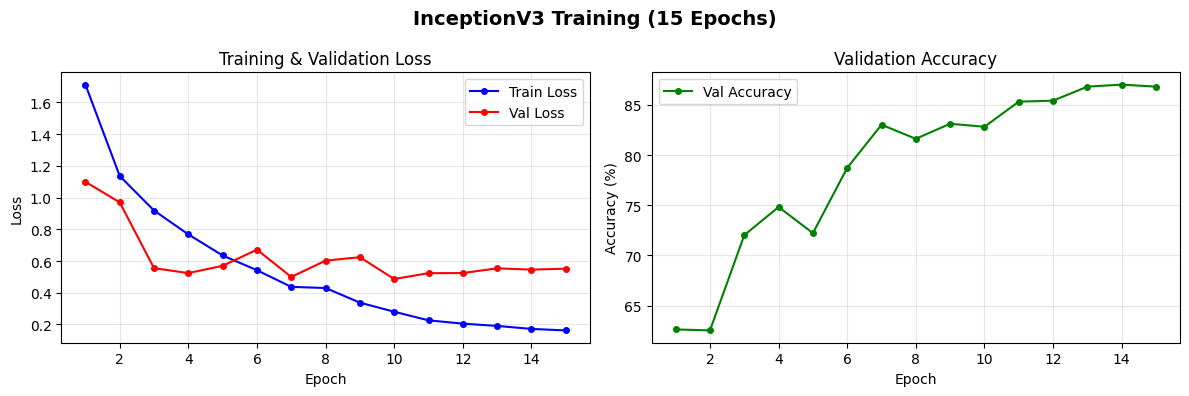

Saved: InceptionV3_15epoch_curves.png


In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(f'{MODEL_NAME} Training (15 Epochs)',
             fontsize=14, fontweight='bold')
 
epochs_range = range(1, NUM_EPOCHS + 1)
 
ax1.plot(epochs_range, train_losses, 'b-o', markersize=4, label='Train Loss')
ax1.plot(epochs_range, val_losses,   'r-o', markersize=4, label='Val Loss')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Training & Validation Loss')
ax1.legend(); ax1.grid(True, alpha=0.3)
 
ax2.plot(epochs_range, val_accs, 'g-o', markersize=4, label='Val Accuracy')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Validation Accuracy')
ax2.legend(); ax2.grid(True, alpha=0.3)
 
plt.tight_layout()
plt.savefig(f'{MODEL_NAME}_15epoch_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {MODEL_NAME}_15epoch_curves.png")

In [8]:
# Load best model
model.load_state_dict(torch.load(f'{MODEL_NAME}_best.pth'))
model.eval()
 
all_probs  = []
all_labels = []
 
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        probs = torch.softmax(outputs, dim=1)
        all_probs.append(probs.cpu().numpy())
        all_labels.append(labels.numpy())
 
all_probs  = np.concatenate(all_probs,  axis=0)  # (N, 7)
all_labels = np.concatenate(all_labels, axis=0)  # (N,)
 
# One-vs-rest AUC per class
y_bin = label_binarize(all_labels, classes=list(range(7)))
auc_scores = {}
for i, name in enumerate(label_names):
    auc = roc_auc_score(y_bin[:, i], all_probs[:, i])
    auc_scores[name] = auc
    print(f'  {name:6s}: AUC = {auc:.4f}')
 
macro_auc = np.mean(list(auc_scores.values()))
print(f'\nMacro-avg AUC: {macro_auc:.4f}')

  nv    : AUC = 0.9664
  mel   : AUC = 0.9309
  bkl   : AUC = 0.9639
  bcc   : AUC = 0.9944
  akiec : AUC = 0.9875
  vasc  : AUC = 0.9999
  df    : AUC = 0.9984

Macro-avg AUC: 0.9773


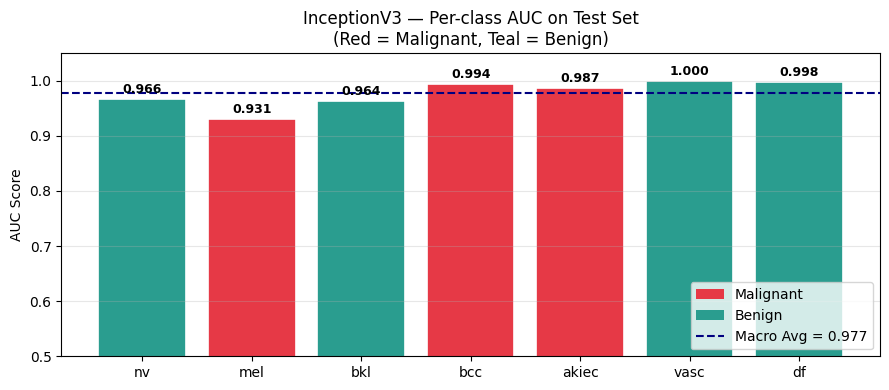

Saved: InceptionV3_per_class_auc.png


In [9]:
fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#E63946' if n in ['mel','bcc','akiec'] else '#2A9D8F'
          for n in label_names]
 
bars = ax.bar(label_names, [auc_scores[n] for n in label_names],
              color=colors, edgecolor='white', linewidth=1.2)
 
# Value labels on bars
for bar, name in zip(bars, label_names):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{auc_scores[name]:.3f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')
 
ax.axhline(macro_auc, color='navy', linestyle='--', linewidth=1.5,
           label=f'Macro Avg AUC = {macro_auc:.3f}')
ax.set_ylim(0.5, 1.05)
ax.set_ylabel('AUC Score')
ax.set_title(f'{MODEL_NAME} — Per-class AUC on Test Set\n'
             f'(Red = Malignant, Teal = Benign)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
 
# Add legend for malignant/benign
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#E63946', label='Malignant'),
                   Patch(facecolor='#2A9D8F', label='Benign')]
ax.legend(handles=legend_elements +
          [plt.Line2D([0],[0], color='navy', linestyle='--',
                      label=f'Macro Avg = {macro_auc:.3f}')],
          loc='lower right')
 
plt.tight_layout()
plt.savefig(f'{MODEL_NAME}_per_class_auc.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {MODEL_NAME}_per_class_auc.png")

In [10]:
# 加载最佳模型
model.load_state_dict(torch.load('InceptionV3_best.pth'))
model.eval()
print("Best model loaded!")

Best model loaded!


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


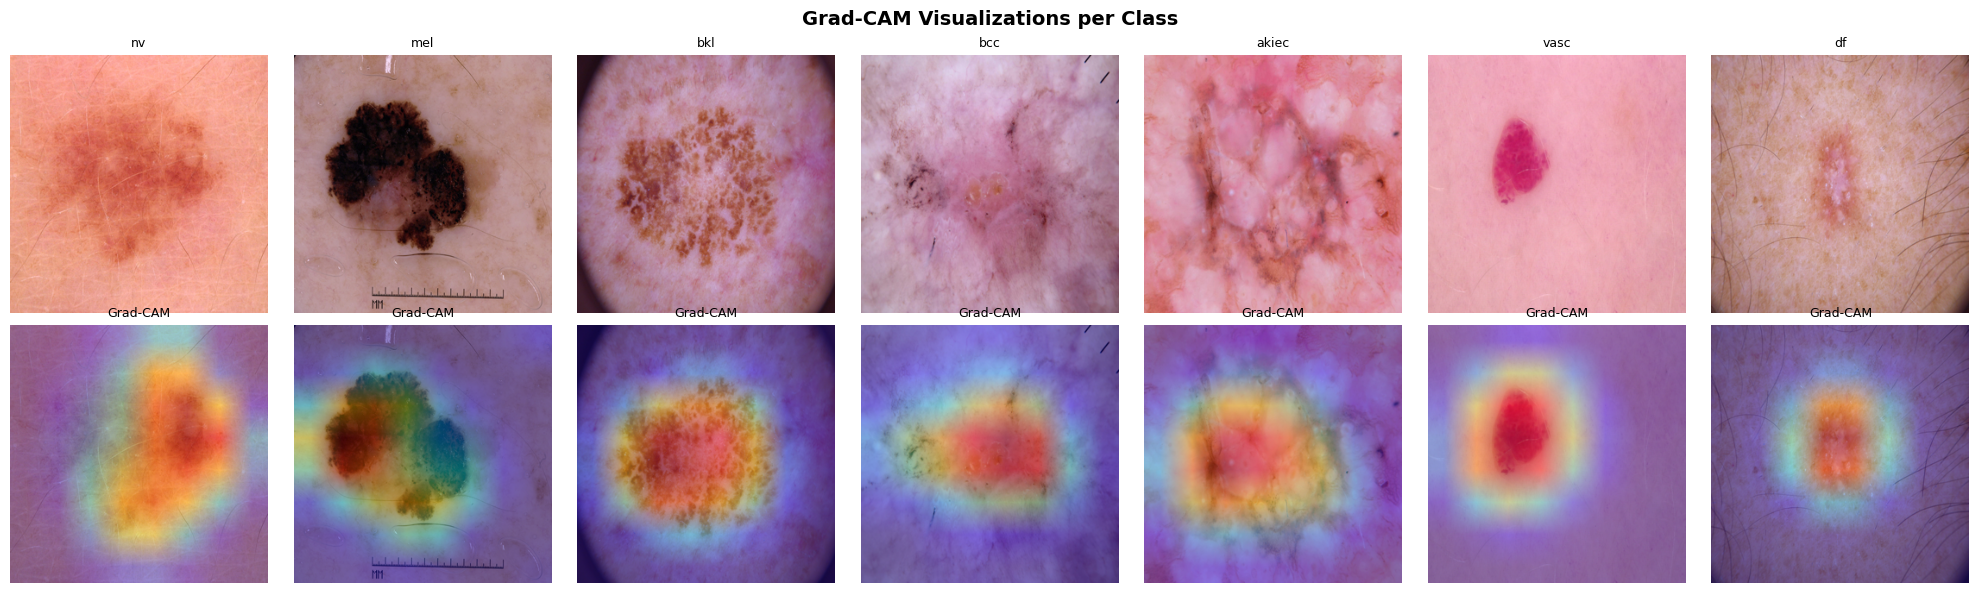

Saved: gradcam_visualization.png


In [11]:
import cv2
import numpy as np
from torchvision import transforms
from PIL import Image

# Grad-CAM实现
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_backward_hook(self._save_gradient)
    
    def _save_activation(self, module, input, output):
        self.activations = output.detach()
    
    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()
    
    def generate(self, input_tensor, class_idx):
        self.model.eval()
        output = self.model(input_tensor)
        self.model.zero_grad()
        
        one_hot = torch.zeros_like(output)
        one_hot[0][class_idx] = 1
        output.backward(gradient=one_hot)
        
        weights = self.gradients.mean(dim=[2, 3], keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = torch.relu(cam)
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam

# 对InceptionV3，target layer是最后一个Mixed block
gradcam = GradCAM(model, model.Mixed_7c)

# 每类取一张test图可视化
label_names = ['nv','mel','bkl','bcc','akiec','vasc','df']
fig, axes = plt.subplots(2, 7, figsize=(20, 6))
fig.suptitle('Grad-CAM Visualizations per Class', fontsize=14, fontweight='bold')

transform_single = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

for i, label_idx in enumerate(range(7)):
    # 取该类第一张test图
    sample = test_df[test_df['label'] == label_idx].iloc[0]
    img_orig = Image.open(sample['path']).convert('RGB')
    img_orig_resized = img_orig.resize((299, 299))
    
    inp = transform_single(img_orig).unsqueeze(0).to(device)
    cam = gradcam.generate(inp, label_idx)
    
    # 热力图叠加
    heatmap = cv2.applyColorMap(
        np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    heatmap = cv2.resize(heatmap, (299, 299))
    overlay = np.array(img_orig_resized) * 0.6 + heatmap * 0.4
    overlay = np.uint8(overlay)
    
    axes[0][i].imshow(img_orig_resized)
    axes[0][i].set_title(label_names[label_idx], fontsize=9)
    axes[0][i].axis('off')
    
    axes[1][i].imshow(overlay)
    axes[1][i].set_title('Grad-CAM', fontsize=9)
    axes[1][i].axis('off')

plt.tight_layout()
plt.savefig('gradcam_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: gradcam_visualization.png")

In [14]:
df = pd.read_csv('/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_metadata.csv')
print(df.columns.tolist())
print(df.head())

['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization']
     lesion_id      image_id   dx dx_type   age   sex localization
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp
2  HAM_0002730  ISIC_0026769  bkl   histo  80.0  male        scalp
3  HAM_0002730  ISIC_0025661  bkl   histo  80.0  male        scalp
4  HAM_0001466  ISIC_0031633  bkl   histo  75.0  male          ear


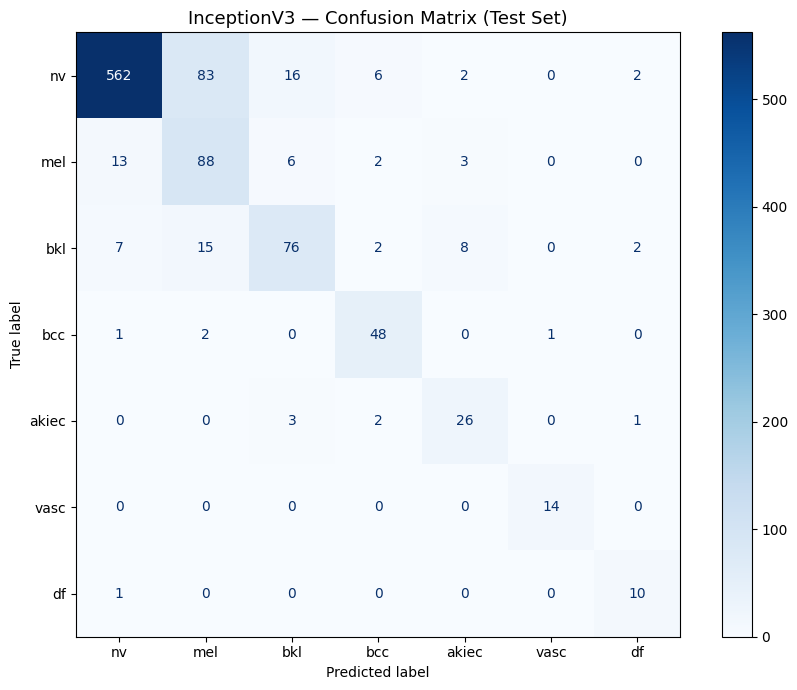

Saved!


In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 收集test set预测
all_preds = []
all_true  = []

model.eval()
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_true.extend(labels.numpy())

# 画混淆矩阵
cm = confusion_matrix(all_true, all_preds)
fig, ax = plt.subplots(figsize=(9, 7))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['nv','mel','bkl','bcc','akiec','vasc','df'])
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title('InceptionV3 — Confusion Matrix (Test Set)', fontsize=13)
plt.tight_layout()
plt.savefig('InceptionV3_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

<40: N=302, Macro AUC=0.9885
40-60: N=411, Macro AUC=0.9819
>60: N=274, Macro AUC=0.9600


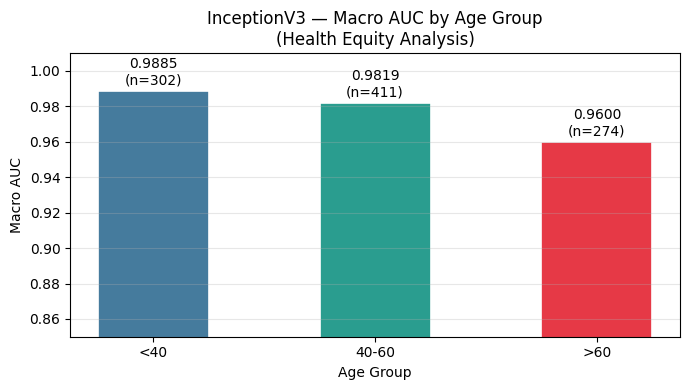

Saved: health_equity_age_auc.png


In [16]:
# 加在test_df里
test_df = test_df.copy()
test_df['age_group'] = pd.cut(
    test_df['age'],
    bins=[0, 40, 60, 100],
    labels=['<40', '40-60', '>60']
)

# 对每个年龄组计算AUC
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize
import numpy as np

# 先跑完整test set预测（你之前已经有all_probs和all_labels了）
# 把age_group加进来
test_df_reset = test_df.reset_index(drop=True)

results = []
for group in ['<40', '40-60', '>60']:
    idx = test_df_reset[test_df_reset['age_group'] == group].index.tolist()
    if len(idx) == 0:
        continue
    probs_g  = all_probs[idx]
    labels_g = all_labels[idx]
    y_bin_g  = label_binarize(labels_g, classes=list(range(7)))
    
    aucs = []
    for i in range(7):
        if len(np.unique(labels_g)) > 1 and y_bin_g[:, i].sum() > 0:
            aucs.append(roc_auc_score(y_bin_g[:, i], probs_g[:, i]))
    macro = np.mean(aucs)
    results.append({'Age Group': group,
                    'N': len(idx),
                    'Macro AUC': round(macro, 4)})
    print(f"{group}: N={len(idx)}, Macro AUC={macro:.4f}")

# 画图
import matplotlib.pyplot as plt
groups = [r['Age Group'] for r in results]
aucs   = [r['Macro AUC'] for r in results]
ns     = [r['N'] for r in results]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(groups, aucs, color=['#457B9D','#2A9D8F','#E63946'],
              edgecolor='white', linewidth=1.2, width=0.5)
for bar, auc, n in zip(bars, aucs, ns):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.002,
            f'{auc:.4f}\n(n={n})',
            ha='center', va='bottom', fontsize=10)
ax.set_ylim(0.85, 1.01)
ax.set_xlabel('Age Group')
ax.set_ylabel('Macro AUC')
ax.set_title('InceptionV3 — Macro AUC by Age Group\n(Health Equity Analysis)')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('health_equity_age_auc.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: health_equity_age_auc.png")